# 2025-04-30 Alpha diversity

## Summary

This notebooks considers the analysis of the beta-diversity in our libraries mapped against the GTDB.

## Data

- Our libraries, after removing reads not mapped at species level, grouping by species, and filtering those with less than 10 reads.

## Analysis

- **PCoA**
- **UniParc**
- **ANCOM**

In [57]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
from skbio.diversity import alpha_diversity, beta_diversity
from skbio import TreeNode
from skbio.stats.ordination import pcoa
from scipy.stats import kruskal

habitat_palette = {
    "Crop": "#0CAB7B", 
    "Edge": "#3A8DFA", 
    "Oak": "#FB2231",
    "Wasteland": "#FFC51F"
}

In [3]:
libraries = pd.read_json("../results/2025-04-21-mmseqs2-preprocess/products/library_species_count-ct10.json").rename(columns={'taxid': "gtdb_id"}).dropna(subset=['species'])

In [4]:
libraries

,library,gtdb_id,level,species_name,phylum,class,order,family,genus,species,Site_code,Collection_code,Host_taxon,Habitat,count,taxonomic_category
0,PV423,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Bromus sp,Oak,56742,7
1,PV428,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Hordeum matritense,Oak,56005,7
2,PV356,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E3,E3P,Hordeum matritense,Wasteland,52262,7
3,PV085,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4P,Avena sterilis,Wasteland,43396,7
4,PV078,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4F,Bromus sp,Wasteland,31948,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31548,PV081,12854,species,Sedimenticola A endophacoides,Pseudomonadota,Gammaproteobacteria,Chromatiales,Sedimenticolaceae,Sedimenticola A,Sedimenticola A endophacoides,L3,L3V,Lithospermum arvense,Edge,11,7
31549,PV201,45335,species,Brevundimonas sp016429195,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas sp016429195,L1,L1F,Convolvulus arvensis,Edge,11,7
31550,PV172,125554,species,Shimia sediminis,Pseudomonadota,Alphaproteobacteria,Rhodobacterales,Rhodobacteraceae,Shimia,Shimia sediminis,L2,L2V,Picris echioides,Edge,11,7
31551,PV011,30806,species,Pseudoalteromonas sp004208945,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Alteromonadaceae,Pseudoalteromonas,Pseudoalteromonas sp004208945,M1,M1V,Portulaca oleraceae,Crop,11,7


#### Counts or not counts?



In [33]:
hits_per_class = libraries.value_counts(
    ['class', 'Site_code', 'Habitat']
).reset_index()
hits_per_class

,class,Site_code,Habitat,count
0,Actinomycetes,L3,Edge,677
1,Actinomycetes,L1,Edge,591
2,Gammaproteobacteria,L3,Edge,548
3,Actinomycetes,Q1,Oak,510
4,Actinomycetes,L2,Edge,499
...,...,...,...,...
1385,Kapaibacteriia,Q3,Oak,1
1386,Kiritimatiellia,C2,Crop,1
1387,Kiritimatiellia,L2,Edge,1
1388,Kiritimatiellia,L3,Edge,1


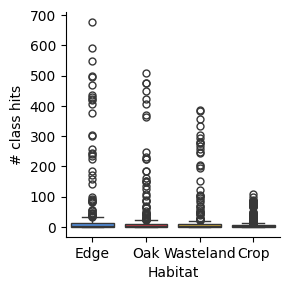

In [35]:

g = sns.catplot(hits_per_class, 
    x='Habitat', y='count', kind='box', height=3.0,
    hue='Habitat', palette=habitat_palette

)
g.set_ylabels("# class hits")

In [38]:
model = smf.glm('count ~ Habitat', data=hits_per_class, family=sm.families.NegativeBinomial()).fit()
print(model.summary2())

                Results: Generalized linear model
Model:                GLM              AIC:            11145.7624
Link Function:        Log              BIC:            -6134.2905
Dependent Variable:   count            Log-Likelihood: -5568.9   
Date:                 2025-05-01 16:54 LL-Null:        -5724.5   
No. Observations:     1390             Deviance:       3896.3    
Df Model:             3                Pearson chi2:   9.08e+03  
Df Residuals:         1386             Scale:          1.0000    
Method:               IRLS                                       
-----------------------------------------------------------------
                     Coef.  Std.Err.    z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------
Intercept            2.3219   0.0493 47.1072 0.0000 2.2253 2.4185
Habitat[T.Edge]      1.3600   0.0795 17.1170 0.0000 1.2043 1.5157
Habitat[T.Oak]       0.8777   0.0743 11.8160 0.0000 0.7321 1.0233
Habitat[T.Wasteland] 0.764

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


In [39]:
model = smf.glm('count ~ Habitat', data=hits_per_class, family=sm.families.Gamma()).fit()
print(model.summary2())

                 Results: Generalized linear model
Model:                 GLM               AIC:             10912.2135
Link Function:         InversePower      BIC:             -5665.8708
Dependent Variable:    count             Log-Likelihood:  -5452.1   
Date:                  2025-05-01 16:54  LL-Null:         -5475.9   
No. Observations:      1390              Deviance:        4364.7    
Df Model:              3                 Pearson chi2:    9.52e+03  
Df Residuals:          1386              Scale:           6.8715    
Method:                IRLS                                         
--------------------------------------------------------------------
                      Coef.  Std.Err.    z    P>|z|   [0.025  0.975]
--------------------------------------------------------------------
Intercept             0.0981   0.0121  8.1104 0.0000  0.0744  0.1218
Habitat[T.Edge]      -0.0729   0.0128 -5.7151 0.0000 -0.0979 -0.0479
Habitat[T.Oak]       -0.0573   0.0134 -4.2696 0.0000

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/statsmodels/genmod/generalized_linear_model.py:308: DomainWarning: The InversePower link function does not respect the domain of the Gamma family.
  warnings.warn((f"The {type(family.link).__name__} link function "


In [41]:
model = smf.glm('count ~ Habitat', data=hits_per_class, family=sm.families.Gaussian()).fit()
print(model.summary2())

                 Results: Generalized linear model
Model:                GLM              AIC:            15684.6742  
Link Function:        Identity         BIC:            6425628.5818
Dependent Variable:   count            Log-Likelihood: -7838.3     
Date:                 2025-05-01 16:54 LL-Null:        -7854.3     
No. Observations:     1390             Deviance:       6.4357e+06  
Df Model:             3                Pearson chi2:   6.44e+06    
Df Residuals:         1386             Scale:          4643.3      
Method:               IRLS                                         
-------------------------------------------------------------------
                      Coef.  Std.Err.   z    P>|z|   [0.025  0.975]
-------------------------------------------------------------------
Intercept            10.1947   3.2051 3.1807 0.0015  3.9128 16.4766
Habitat[T.Edge]      29.5250   5.2784 5.5936 0.0000 19.1796 39.8704
Habitat[T.Oak]       14.3276   4.9042 2.9215 0.0035  4.7155 23.93

#### Format data

I am following the docs at [this link](https://scikit.bio/docs/dev/diversity.html). It seems that skbio.diversity.beta_diversity requires data to be formatted as a matrix, where each row is a sample and each column is the count of a given taxon. Therefore, we need to pivot our table.

In [43]:
rank = 'class'
N = 20
A = libraries.value_counts(['gtdb_id', 'Habitat', 'Site_code', rank]).reset_index()
B = libraries.value_counts(['Site_code']).reset_index()
sites_ar = pd.merge(A, B, on='Site_code', suffixes=['', '_total'])
sites_ar['AR'] = sites_ar['count'] / sites_ar['count_total']
rank_counts = libraries.value_counts(['gtdb_id', rank]).reset_index().value_counts([rank]).reset_index()
topN_ranks = rank_counts[rank][:N].tolist()
sites_ar

,gtdb_id,Habitat,Site_code,class,count,count_total,AR
0,57157,Edge,L1,Alphaproteobacteria,40,3092,0.012937
1,46402,Edge,L1,Verrucomicrobiae,40,3092,0.012937
2,126240,Edge,L1,Cyanobacteriia,40,3092,0.012937
3,55151,Edge,L1,Bacilli,40,3092,0.012937
4,3824,Edge,L1,Clostridia,40,3092,0.012937
...,...,...,...,...,...,...,...
8567,77768,Edge,L2,Gammaproteobacteria,1,2677,0.000374
8568,99114,Crop,M4,Gammaproteobacteria,1,306,0.003268
8569,77749,Oak,Q1,Verrucomicrobiae,1,3075,0.000325
8570,49843,Oak,Q4,Gammaproteobacteria,1,1528,0.000654


In [44]:
libraries_bysite_pvt = sites_ar.groupby(
    ['Site_code', 'Habitat', 'class'], as_index=False
)['AR'].sum().pivot(
    index=['Site_code', 'Habitat'], columns='class', values='AR'
).fillna(0.0).reset_index()
libraries_bysite_pvt

class,Site_code,Habitat,2-12-FULL-62-27,ABY1,Abditibacteriia,Acidimicrobiia,Actinomycetes,Alphaproteobacteria,Anaerolineae,Aquificae,...,Vampirovibrionia,Verrucomicrobiae,Vicinamibacteria,WGA-4E,WOR-3,WWE3,WYAZ01,XYA12-FULL-58-9,Xenobia,YA12-FULL-61-11
0,C1,Crop,0.000000,0.000000,0.000000,0.014493,0.173913,0.151139,0.000000,0.000000,...,0.000000,0.026915,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,C2,Crop,0.000000,0.000000,0.000000,0.010830,0.198556,0.157040,0.000000,0.000000,...,0.000000,0.036101,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,E1,Wasteland,0.000000,0.001423,0.000000,0.015658,0.172954,0.143772,0.005694,0.000000,...,0.000712,0.034164,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000712,0.000000
3,E2,Wasteland,0.000000,0.000000,0.000000,0.013875,0.156732,0.141829,0.003597,0.000000,...,0.000514,0.025694,0.000514,0.000000,0.002569,0.000514,0.000000,0.000000,0.000000,0.000000
4,E3,Wasteland,0.000000,0.000572,0.000000,0.012593,0.152261,0.141385,0.004007,0.000000,...,0.000000,0.030910,0.000000,0.000000,0.001145,0.000572,0.000000,0.000000,0.000000,0.000000
5,E4,Wasteland,0.000000,0.000000,0.000000,0.017990,0.168934,0.157086,0.002633,0.001316,...,0.000000,0.030715,0.000000,0.001316,0.000439,0.000000,0.000439,0.000000,0.000000,0.000000
6,H1,Crop,0.000000,0.000000,0.000000,0.014286,0.071429,0.109524,0.000000,0.000000,...,0.000000,0.033333,0.000000,0.000000,0.004762,0.000000,0.000000,0.000000,0.000000,0.000000
7,H2,Crop,0.000000,0.003300,0.000000,0.013201,0.224422,0.122112,0.000000,0.000000,...,0.000000,0.036304,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,H3,Crop,0.000000,0.000000,0.000000,0.018987,0.166667,0.137131,0.000000,0.000000,...,0.002110,0.027426,0.000000,0.000000,0.002110,0.000000,0.000000,0.000000,0.002110,0.000000
9,L1,Edge,0.000323,0.000000,0.000000,0.018111,0.191138,0.141332,0.001940,0.000000,...,0.000647,0.031695,0.000000,0.000000,0.000000,0.000323,0.000000,0.000000,0.000000,0.000000


In [48]:
libraries_bysite_pvt.loc[5][libraries_bysite_pvt.columns[2:]].sum()

1.000000000000001

In [ ]:
data = libraries_bysite_pvt[libraries_bysite_pvt.columns[2:]].values
ids = libraries_bysite_pvt['Site_code'].values

In [50]:
tree = TreeNode.read("../data/taxonomy/bac120.tree")
tree_tip_names = list(tree.subset())
mapping_genomes = pd.read_csv("../data/taxonomy/gtdb-taxdump/mapping_genomes", header=None, sep="\t", names=['genome', 'gtdb_id'])
mapping_genomes['genome'] = mapping_genomes['genome'].apply(lambda x: x.replace("_", " "))
mapping_genomes['is_tip'] = mapping_genomes['genome'].isin(tree_tip_names)
mapping_genomes = mapping_genomes.query('is_tip == True')[['genome', 'gtdb_id']].copy()
libraries = pd.merge(libraries, mapping_genomes, on='gtdb_id')
libraries

,library,gtdb_id,level,species_name,phylum,class,order,family,genus,species,Site_code,Collection_code,Host_taxon,Habitat,count,taxonomic_category,genome_x,genome_y
0,PV423,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Bromus sp,Oak,56742,7,GB GCA 937139475.1,GB GCA 937139475.1
1,PV428,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Hordeum matritense,Oak,56005,7,GB GCA 937139475.1,GB GCA 937139475.1
2,PV356,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E3,E3P,Hordeum matritense,Wasteland,52262,7,GB GCA 937139475.1,GB GCA 937139475.1
3,PV085,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4P,Avena sterilis,Wasteland,43396,7,GB GCA 937139475.1,GB GCA 937139475.1
4,PV078,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4F,Bromus sp,Wasteland,31948,7,GB GCA 937139475.1,GB GCA 937139475.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30730,PV081,12854,species,Sedimenticola A endophacoides,Pseudomonadota,Gammaproteobacteria,Chromatiales,Sedimenticolaceae,Sedimenticola A,Sedimenticola A endophacoides,L3,L3V,Lithospermum arvense,Edge,11,7,GB GCA 003062205.1,GB GCA 003062205.1
30731,PV201,45335,species,Brevundimonas sp016429195,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas sp016429195,L1,L1F,Convolvulus arvensis,Edge,11,7,GB GCA 016429195.1,GB GCA 016429195.1
30732,PV172,125554,species,Shimia sediminis,Pseudomonadota,Alphaproteobacteria,Rhodobacterales,Rhodobacteraceae,Shimia,Shimia sediminis,L2,L2V,Picris echioides,Edge,11,7,RS GCF 003990645.1,RS GCF 003990645.1
30733,PV011,30806,species,Pseudoalteromonas sp004208945,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Alteromonadaceae,Pseudoalteromonas,Pseudoalteromonas sp004208945,M1,M1V,Portulaca oleraceae,Crop,11,7,GB GCA 004208945.1,GB GCA 004208945.1


In [58]:
bc_dm = beta_diversity('braycurtis', data, ids=ids)

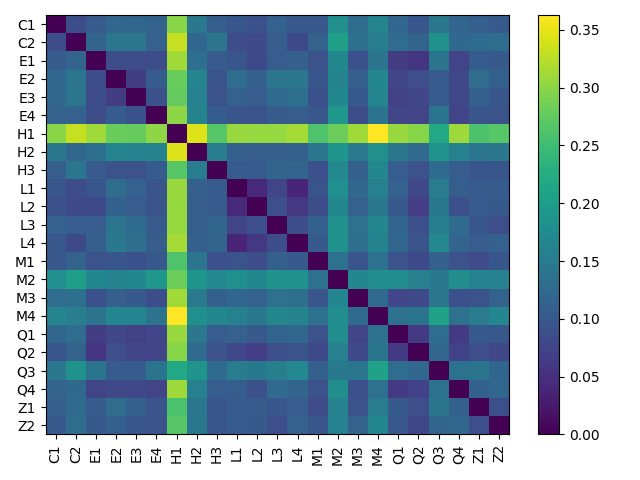

In [59]:
bc_dm

Text(8.0, 58.45648054892219, '  58.5 %')

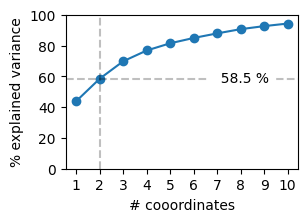

In [93]:
pc = pcoa(bc_dm, number_of_dimensions=10)
fig, ax = plt.subplots(1)
fig.set_size_inches(3,2)
ax.plot(np.arange(1, 11), 100 * pc.proportion_explained.values.cumsum(), marker='o')
ax.set_ylim([0, 100])
ax.set_xticks(np.arange(1, 11))
ax.set_ylabel(r"% explained variance")
ax.set_xlabel(r"# cooordinates")
ax.axvline(2.0, color='black', linestyle='--', alpha=0.25)
ax.axhline(100 * pc.proportion_explained.values.cumsum()[1], color='black', linestyle='--', alpha=0.25)
ax.text(
    8.0, 100 * pc.proportion_explained.values.cumsum()[1], 
    "{0:6.1f} %".format(100 * pc.proportion_explained.values.cumsum()[1]) ,
    horizontalalignment='center', verticalalignment='center', bbox=dict(facecolor='white', alpha=1.0, edgecolor='white')
)

In [94]:
pcsamples = pd.merge(
    pc.samples.copy().reset_index().rename(columns={'index': 'Site_code'}), 
    libraries[['Site_code', 'Habitat']].drop_duplicates(keep='first'),
    on='Site_code'
)

Text(0.28182940257580036, 0.034594771225646685, 'H1')

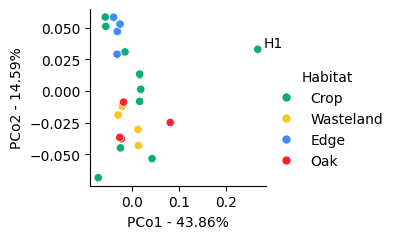

In [104]:
g = sns.relplot(data=pcsamples[['PC1', 'PC2', 'Habitat']], x="PC1", y="PC2", hue='Habitat', height=2.5, aspect=1.25, palette=habitat_palette)
g.set_xlabels("PCo1 - {0:5.2f}%".format(pc.proportion_explained.tolist()[0] * 100))
g.set_ylabels("PCo2 - {0:5.2f}%".format(pc.proportion_explained.tolist()[1] * 100))
g.axes[0, 0].text(
    pcsamples.query('PC1 > 0.2')['PC1'].values[0] * 1.05, 
    pcsamples.query('PC1 > 0.2')['PC2'].values[0] * 1.05, pcsamples.query('PC1 > 0.2')['Site_code'].values[0])

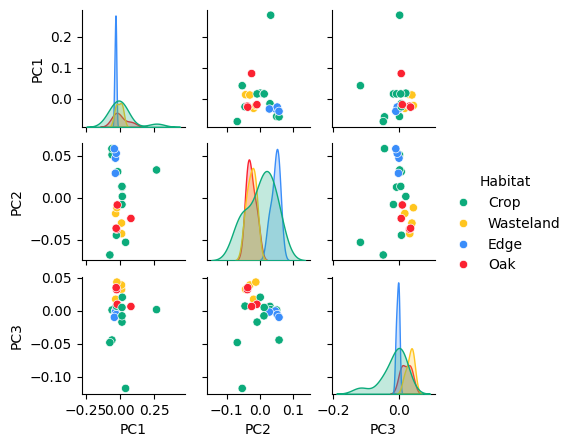

In [96]:
sns.pairplot(data=pcsamples[['PC1', 'PC2', 'PC3', 'Habitat']], hue='Habitat', height=1.5, palette=habitat_palette)

In [97]:
from skbio.stats.distance import permanova

In [98]:
habitats = pcsamples['Habitat'].values
permanova(bc_dm, habitats)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      23
number of groups                  4
test statistic             1.308759
p-value                       0.186
number of permutations          999
Name: PERMANOVA results, dtype: object

In [106]:
from scipy.cluster.hierarchy import dendrogram, linkage

/tmp/ipykernel_852755/384161902.py:1: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  Z = linkage(bc_dm.data, 'ward')


Text(0.5, 0, 'Distance')

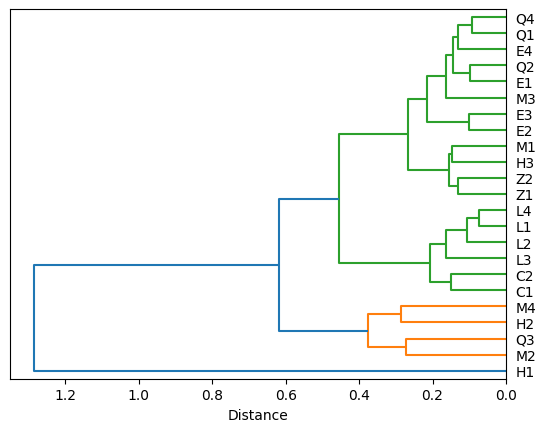

In [110]:
Z = linkage(bc_dm.data, 'ward')
fig, ax = plt.subplots(1)
d = dendrogram(Z, orientation='left', labels=bc_dm.ids, ax=ax, color_threshold=0.5)
ax.set_xlabel("Distance")

In [112]:
def relative_abundance_topN_rank(libraries, rank, N):
    sites_ar = pd.merge(
        libraries.value_counts(['gtdb_id', 'Habitat', 'Site_code', rank]).reset_index(), 
        libraries.value_counts(['Site_code']).reset_index(), 
        on='Site_code', suffixes=['', '_total']
    )
    sites_ar['AR'] = sites_ar['count'] / sites_ar['count_total']
    rank_counts = libraries.value_counts(['gtdb_id', rank]).reset_index().value_counts([rank]).reset_index()
    topN_ranks = rank_counts[rank][:N].tolist()
    
    sites_ar[f'top{N}_{rank}'] = sites_ar[rank].apply(lambda x: "others" if x not in topN_ranks else x)
    return sites_ar

In [113]:
relative_abundance_topN_rank(libraries, 'class', 20)

,gtdb_id,Habitat,Site_code,class,count,count_total,AR,top20_class
0,57157,Edge,L1,Alphaproteobacteria,40,3092,0.012937,Alphaproteobacteria
1,46402,Edge,L1,Verrucomicrobiae,40,3092,0.012937,Verrucomicrobiae
2,126240,Edge,L1,Cyanobacteriia,40,3092,0.012937,Cyanobacteriia
3,55151,Edge,L1,Bacilli,40,3092,0.012937,Bacilli
4,3824,Edge,L1,Clostridia,40,3092,0.012937,Clostridia
...,...,...,...,...,...,...,...,...
8567,77768,Edge,L2,Gammaproteobacteria,1,2677,0.000374,Gammaproteobacteria
8568,99114,Crop,M4,Gammaproteobacteria,1,306,0.003268,Gammaproteobacteria
8569,77749,Oak,Q1,Verrucomicrobiae,1,3075,0.000325,Verrucomicrobiae
8570,49843,Oak,Q4,Gammaproteobacteria,1,1528,0.000654,Gammaproteobacteria


In [114]:
from scipy.spatial.distance import braycurtis

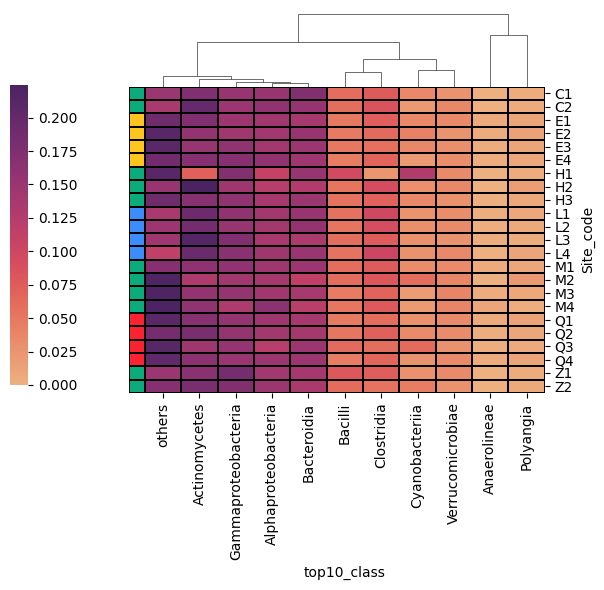

In [140]:
rank = 'class'
N = 10
sites_ar = relative_abundance_topN_rank(libraries, rank, N).groupby(
        ['Site_code', 'Habitat', f'top{N}_{rank}'], as_index=False)['AR'].sum()


sites_ar_pvt = sites_ar.pivot(index=['Site_code', 'Habitat'], columns=f'top{N}_{rank}', values='AR').reset_index().fillna(0.0)

row_colors = [habitat_palette[item] for item in sites_ar_pvt['Habitat']]
g = sns.clustermap(
    sites_ar_pvt.drop(columns=['Habitat']).set_index('Site_code'), 
    cmap='flare', 
    figsize=(6, 6), metric=braycurtis, row_colors=row_colors, 
    col_cluster=True, row_cluster=False, # vmin=0.0,
    linewidth=0.01, linecolor='black', cbar_pos=[0., 0.35, 0.03, 0.5]
)
sorted_labels = list(map(lambda x: x.get_text(), g.ax_heatmap.get_yticklabels()))

class,Site_code,Habitat,2-12-FULL-62-27,ABY1,Abditibacteriia,Acidimicrobiia,Actinomycetes,Alphaproteobacteria,Anaerolineae,Aquificae,...,Vampirovibrionia,Verrucomicrobiae,Vicinamibacteria,WGA-4E,WOR-3,WWE3,WYAZ01,XYA12-FULL-58-9,Xenobia,YA12-FULL-61-11
0,C1,Crop,0.000000,0.000000,0.000000,0.014493,0.173913,0.151139,0.000000,0.000000,...,0.000000,0.026915,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,C2,Crop,0.000000,0.000000,0.000000,0.010830,0.198556,0.157040,0.000000,0.000000,...,0.000000,0.036101,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,E1,Wasteland,0.000000,0.001423,0.000000,0.015658,0.172954,0.143772,0.005694,0.000000,...,0.000712,0.034164,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000712,0.000000
3,E2,Wasteland,0.000000,0.000000,0.000000,0.013875,0.156732,0.141829,0.003597,0.000000,...,0.000514,0.025694,0.000514,0.000000,0.002569,0.000514,0.000000,0.000000,0.000000,0.000000
4,E3,Wasteland,0.000000,0.000572,0.000000,0.012593,0.152261,0.141385,0.004007,0.000000,...,0.000000,0.030910,0.000000,0.000000,0.001145,0.000572,0.000000,0.000000,0.000000,0.000000
5,E4,Wasteland,0.000000,0.000000,0.000000,0.017990,0.168934,0.157086,0.002633,0.001316,...,0.000000,0.030715,0.000000,0.001316,0.000439,0.000000,0.000439,0.000000,0.000000,0.000000
7,H2,Crop,0.000000,0.003300,0.000000,0.013201,0.224422,0.122112,0.000000,0.000000,...,0.000000,0.036304,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
8,H3,Crop,0.000000,0.000000,0.000000,0.018987,0.166667,0.137131,0.000000,0.000000,...,0.002110,0.027426,0.000000,0.000000,0.002110,0.000000,0.000000,0.000000,0.002110,0.000000
9,L1,Edge,0.000323,0.000000,0.000000,0.018111,0.191138,0.141332,0.001940,0.000000,...,0.000647,0.031695,0.000000,0.000000,0.000000,0.000323,0.000000,0.000000,0.000000,0.000000
10,L2,Edge,0.000000,0.000000,0.000000,0.016810,0.186403,0.140829,0.002241,0.000000,...,0.001121,0.033620,0.000000,0.000000,0.000000,0.000374,0.000000,0.000000,0.000747,0.000374


In [145]:
data = libraries_bysite_pvt.query('Site_code != "H1"')[libraries_bysite_pvt.columns[2:]].values
ids = libraries_bysite_pvt.query('Site_code != "H1"')['Site_code'].values
bc_dm = beta_diversity('braycurtis', data, ids=ids)
habitats = libraries_bysite_pvt.query('Site_code != "H1"')['Habitat'].values
permanova(bc_dm, habitats)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      22
number of groups                  4
test statistic             1.832402
p-value                       0.011
number of permutations          999
Name: PERMANOVA results, dtype: object

/home/bcz/miniconda3/envs/miripvir25/lib/python3.9/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:214: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.0004200857385286151 whereas the largest positive one is 0.0407171296631344.
  warn(


Text(8.0, 43.57826273779173, '  43.6 %')

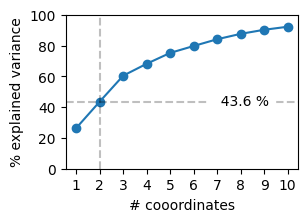

In [146]:
pc = pcoa(bc_dm, number_of_dimensions=10)
fig, ax = plt.subplots(1)
fig.set_size_inches(3,2)
ax.plot(np.arange(1, 11), 100 * pc.proportion_explained.values.cumsum(), marker='o')
ax.set_ylim([0, 100])
ax.set_xticks(np.arange(1, 11))
ax.set_ylabel(r"% explained variance")
ax.set_xlabel(r"# cooordinates")
ax.axvline(2.0, color='black', linestyle='--', alpha=0.25)
ax.axhline(100 * pc.proportion_explained.values.cumsum()[1], color='black', linestyle='--', alpha=0.25)
ax.text(
    8.0, 100 * pc.proportion_explained.values.cumsum()[1], 
    "{0:6.1f} %".format(100 * pc.proportion_explained.values.cumsum()[1]) ,
    horizontalalignment='center', verticalalignment='center', bbox=dict(facecolor='white', alpha=1.0, edgecolor='white')
)

In [148]:
pcsamples = pd.merge(
    pc.samples.copy().reset_index().rename(columns={'index': 'Site_code'}), 
    libraries[['Site_code', 'Habitat']].drop_duplicates(keep='first'),
    on='Site_code', how='left'
)

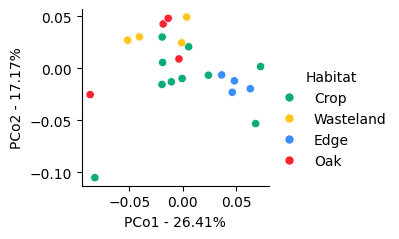

In [150]:
g = sns.relplot(data=pcsamples[['PC1', 'PC2', 'Habitat']], x="PC1", y="PC2", hue='Habitat', height=2.5, aspect=1.25, palette=habitat_palette)
g.set_xlabels("PCo1 - {0:5.2f}%".format(pc.proportion_explained.tolist()[0] * 100))
g.set_ylabels("PCo2 - {0:5.2f}%".format(pc.proportion_explained.tolist()[1] * 100))
# g.axes[0, 0].text()

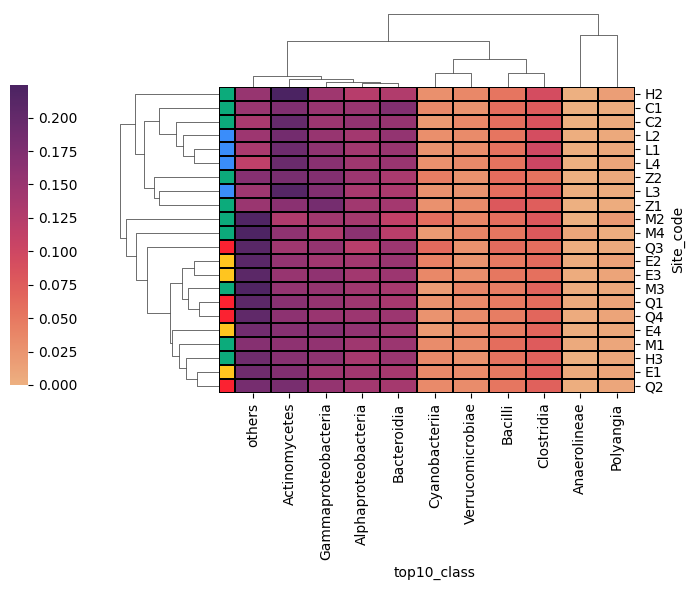

In [153]:
rank = 'class'
N = 10
sites_ar = relative_abundance_topN_rank(libraries.query('Site_code != "H1"'), rank, N).groupby(
        ['Site_code', 'Habitat', f'top{N}_{rank}'], as_index=False)['AR'].sum()


sites_ar_pvt = sites_ar.pivot(index=['Site_code', 'Habitat'], columns=f'top{N}_{rank}', values='AR').reset_index().fillna(0.0)

row_colors = [habitat_palette[item] for item in sites_ar_pvt['Habitat']]
g = sns.clustermap(
    sites_ar_pvt.drop(columns=['Habitat']).set_index('Site_code'), 
    cmap='flare', 
    figsize=(6, 6), metric=braycurtis, row_colors=row_colors, 
    col_cluster=True, row_cluster=True, # vmin=0.0,
    linewidth=0.01, linecolor='black', cbar_pos=[-0.15, 0.35, 0.03, 0.5]
)
sorted_labels = list(map(lambda x: x.get_text(), g.ax_heatmap.get_yticklabels()))

### UniParc

In [154]:
libraries = pd.read_json("../results/2025-04-21-mmseqs2-preprocess/products/library_species_count-ct10.json").rename(columns={'taxid': "gtdb_id"}).dropna(subset=['species'])
tree = TreeNode.read("../data/taxonomy/bac120.tree")
tree_tip_names = list(tree.subset())
mapping_genomes = pd.read_csv("../data/taxonomy/gtdb-taxdump/mapping_genomes", header=None, sep="\t", names=['genome', 'gtdb_id'])
mapping_genomes['genome'] = mapping_genomes['genome'].apply(lambda x: x.replace("_", " "))
mapping_genomes['is_tip'] = mapping_genomes['genome'].isin(tree_tip_names)
mapping_genomes = mapping_genomes.query('is_tip == True')[['genome', 'gtdb_id']].copy()
mapping_genomes
libraries = pd.merge(libraries, mapping_genomes, on='gtdb_id')
libraries

,library,gtdb_id,level,species_name,phylum,class,order,family,genus,species,Site_code,Collection_code,Host_taxon,Habitat,count,taxonomic_category,genome
0,PV423,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Bromus sp,Oak,56742,7,GB GCA 937139475.1
1,PV428,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,Q1,Q1P,Hordeum matritense,Oak,56005,7,GB GCA 937139475.1
2,PV356,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E3,E3P,Hordeum matritense,Wasteland,52262,7,GB GCA 937139475.1
3,PV085,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4P,Avena sterilis,Wasteland,43396,7,GB GCA 937139475.1
4,PV078,94383,species,Psychrobium sp937139475,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Psychrobiaceae,Psychrobium,Psychrobium sp937139475,E4,E4F,Bromus sp,Wasteland,31948,7,GB GCA 937139475.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30730,PV081,12854,species,Sedimenticola A endophacoides,Pseudomonadota,Gammaproteobacteria,Chromatiales,Sedimenticolaceae,Sedimenticola A,Sedimenticola A endophacoides,L3,L3V,Lithospermum arvense,Edge,11,7,GB GCA 003062205.1
30731,PV201,45335,species,Brevundimonas sp016429195,Pseudomonadota,Alphaproteobacteria,Caulobacterales,Caulobacteraceae,Brevundimonas,Brevundimonas sp016429195,L1,L1F,Convolvulus arvensis,Edge,11,7,GB GCA 016429195.1
30732,PV172,125554,species,Shimia sediminis,Pseudomonadota,Alphaproteobacteria,Rhodobacterales,Rhodobacteraceae,Shimia,Shimia sediminis,L2,L2V,Picris echioides,Edge,11,7,RS GCF 003990645.1
30733,PV011,30806,species,Pseudoalteromonas sp004208945,Pseudomonadota,Gammaproteobacteria,Enterobacterales,Alteromonadaceae,Pseudoalteromonas,Pseudoalteromonas sp004208945,M1,M1V,Portulaca oleraceae,Crop,11,7,GB GCA 004208945.1


In [160]:
rank = 'class'
N = 20
A = libraries.value_counts(['gtdb_id', 'Habitat', 'Site_code', 'genome', rank]).reset_index()
B = libraries.value_counts(['Site_code']).reset_index()
sites_ar = pd.merge(A, B, on='Site_code', suffixes=['', '_total'])
sites_ar['AR'] = sites_ar['count'] / sites_ar['count_total']
rank_counts = libraries.value_counts(['gtdb_id', rank]).reset_index().value_counts([rank]).reset_index()
topN_ranks = rank_counts[rank][:N].tolist()
sites_ar

,gtdb_id,Habitat,Site_code,genome,class,count,count_total,AR
0,57157,Edge,L1,GB GCA 902729415.1,Alphaproteobacteria,40,3092,0.012937
1,46402,Edge,L1,GB GCA 027487435.1,Verrucomicrobiae,40,3092,0.012937
2,126240,Edge,L1,GB GCA 936914905.1,Cyanobacteriia,40,3092,0.012937
3,55151,Edge,L1,GB GCA 003640645.1,Bacilli,40,3092,0.012937
4,3824,Edge,L1,GB GCA 009911305.1,Clostridia,40,3092,0.012937
...,...,...,...,...,...,...,...,...
8567,77768,Edge,L2,GB GCA 001801575.1,Gammaproteobacteria,1,2677,0.000374
8568,99114,Crop,M4,RS GCF 009910675.1,Gammaproteobacteria,1,306,0.003268
8569,77749,Oak,Q1,GB GCA 013695925.1,Verrucomicrobiae,1,3075,0.000325
8570,49843,Oak,Q4,GB GCA 000761495.1,Gammaproteobacteria,1,1528,0.000654


In [228]:
libraries_bysite_pvt = sites_ar.query('Site_code != "H1"').groupby(
    ['Site_code', 'Habitat', 'gtdb_id'], as_index=False
)['count'].sum().pivot(
    index=['Site_code', 'Habitat'], columns='gtdb_id', values='count'
).fillna(0.0).reset_index()
data = libraries_bysite_pvt[libraries_bysite_pvt.columns[2:]].values
ids = libraries_bysite_pvt['Site_code'].values
habitats = libraries_bysite_pvt['Habitat'].values
taxa = sites_ar.query('Site_code != "H1"')['genome'].unique()

In [202]:
np.shape(data[:2, :])

(2, 2320)

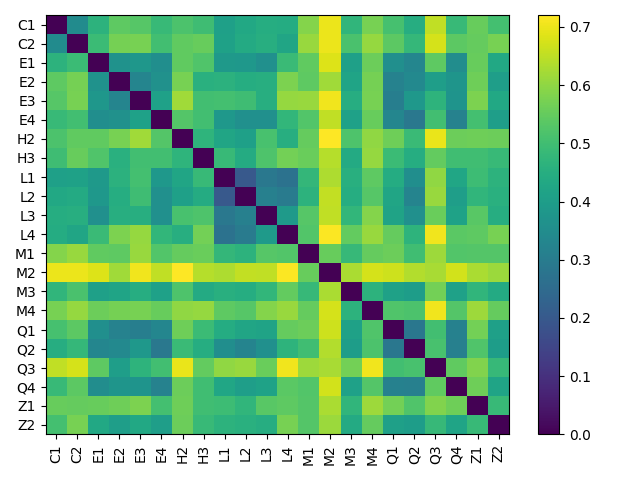

In [205]:
wu_dm = beta_diversity("weighted_unifrac", data[:, :], ids[:], tree=tree, taxa=taxa)
wu_dm


In [223]:
wu_dm_df = pd.DataFrame(wu_dm.data, columns=ids, index=ids).reset_index()
wu_dm_df = wu_dm_df.melt(id_vars='index', value_vars=ids).rename(columns={'index': 'Site_code_1', 'variable': 'Site_code_2'})
wu_dm_df = pd.merge(wu_dm_df, libraries[['Site_code', 'Habitat']].drop_duplicates(keep='first').rename(columns={'Habitat': 'Habitat1'}), left_on='Site_code_1', right_on='Site_code', how='left')
wu_dm_df = pd.merge(wu_dm_df, libraries[['Site_code', 'Habitat']].drop_duplicates(keep='first').rename(columns={'Habitat': 'Habitat2'}), left_on='Site_code_2', right_on='Site_code', how='left')
wu_dm_df['is_interhabitat'] = wu_dm_df['Habitat1'] != wu_dm_df['Habitat2']
wu_dm_df = wu_dm_df[wu_dm_df['Site_code_1'] != wu_dm_df['Site_code_2']]
wu_dm_df[['Site_code_1', 'Site_code_2', 'value', 'Habitat1', 'Habitat2', 'is_interhabitat']]

,Site_code_1,Site_code_2,value,Habitat1,Habitat2,is_interhabitat
1,C2,C1,0.343404,Crop,Crop,False
2,E1,C1,0.463779,Wasteland,Crop,True
3,E2,C1,0.542868,Wasteland,Crop,True
4,E3,C1,0.531638,Wasteland,Crop,True
5,E4,C1,0.486540,Wasteland,Crop,True
...,...,...,...,...,...,...
478,Q1,Z2,0.406877,Oak,Crop,True
479,Q2,Z2,0.399061,Oak,Crop,True
480,Q3,Z2,0.483465,Oak,Crop,True
481,Q4,Z2,0.420472,Oak,Crop,True


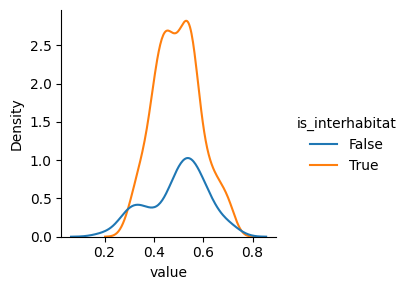

In [225]:
sns.displot(wu_dm_df, x='value', hue='is_interhabitat', kind='kde', height=3.0)

In [229]:
permanova(wu_dm, habitats)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                      22
number of groups                  4
test statistic             2.063567
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

Text(8.0, 36.43369043546104, '  36.4 %')

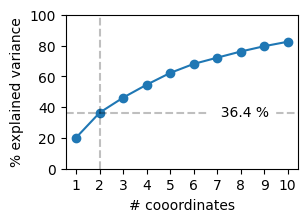

In [230]:
pc = pcoa(wu_dm, number_of_dimensions=10)
fig, ax = plt.subplots(1)
fig.set_size_inches(3,2)
ax.plot(np.arange(1, 11), 100 * pc.proportion_explained.values.cumsum(), marker='o')
ax.set_ylim([0, 100])
ax.set_xticks(np.arange(1, 11))
ax.set_ylabel(r"% explained variance")
ax.set_xlabel(r"# cooordinates")
ax.axvline(2.0, color='black', linestyle='--', alpha=0.25)
ax.axhline(100 * pc.proportion_explained.values.cumsum()[1], color='black', linestyle='--', alpha=0.25)
ax.text(
    8.0, 100 * pc.proportion_explained.values.cumsum()[1], 
    "{0:6.1f} %".format(100 * pc.proportion_explained.values.cumsum()[1]) ,
    horizontalalignment='center', verticalalignment='center', bbox=dict(facecolor='white', alpha=1.0, edgecolor='white')
)

In [231]:
pcsamples = pd.merge(
    pc.samples.copy().reset_index().rename(columns={'index': 'Site_code'}), 
    libraries[['Site_code', 'Habitat']].drop_duplicates(keep='first'),
    on='Site_code', how='left'
)

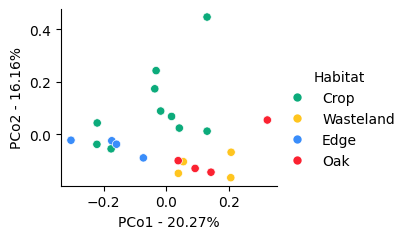

In [232]:
g = sns.relplot(data=pcsamples[['PC1', 'PC2', 'Habitat']], x="PC1", y="PC2", hue='Habitat', height=2.5, aspect=1.25, palette=habitat_palette)
g.set_xlabels("PCo1 - {0:5.2f}%".format(pc.proportion_explained.tolist()[0] * 100))
g.set_ylabels("PCo2 - {0:5.2f}%".format(pc.proportion_explained.tolist()[1] * 100))
# g.axes[0, 0].text()

Text(0.5, 0, 'Distance')

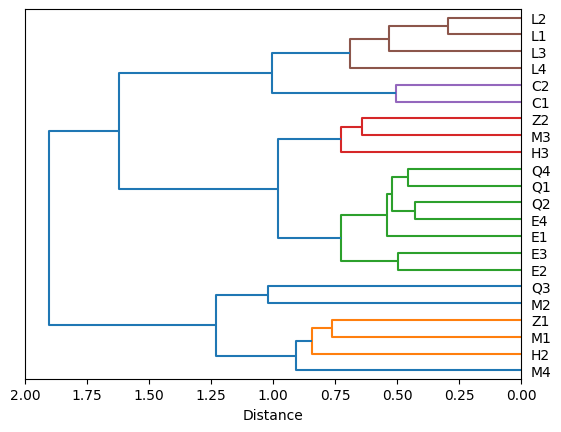

In [256]:
Z = linkage(wu_dm.data, 'ward')
fig, ax = plt.subplots(1)
d = dendrogram(Z, orientation='left', labels=bc_dm.ids, ax=ax, color_threshold=0.9)
ax.set_xlabel("Distance")

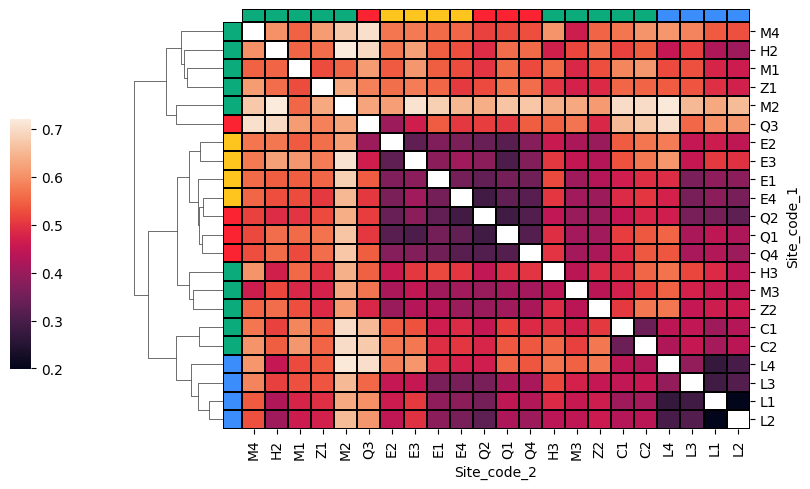

In [271]:
wu_dm_df_pvt = wu_dm_df.pivot(index=['Site_code_1', 'Habitat1'], columns='Site_code_2', values='value').fillna(0.0).reset_index()
row_colors = [habitat_palette[item] for item in wu_dm_df_pvt['Habitat1']]
sns.clustermap(
    wu_dm_df_pvt.drop(columns='Habitat1').set_index('Site_code_1'), 
    mask=np.eye(len(wu_dm_df_pvt)), col_cluster=True, figsize=(7, 5),
    row_colors=row_colors, col_colors=row_colors, linewidth=0.1, linecolor='black',
    row_linkage=Z, col_linkage=Z,cbar_pos=[-0.15, 0.25, 0.03, 0.5], dendrogram_ratio=[0.15, 0.0]
)